# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import itertools
import string
from pathlib import Path
from typing import Iterable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM Pride in Preduice
seq_products = itertools.product(string.ascii_uppercase, repeat=4)
filter_seq_products = (
    ''.join(p)
    for i, p in enumerate(seq_products)
    if len(set(p)) in (1, 3)
)
filter_seq_products = itertools.islice(filter_seq_products, None, None, 127)
filter_seq_products = (x for i,x in enumerate(filter_seq_products) if i < 1000)


def print_text_wrap(seq: Iterable[str]):
    line_chars = 0
    pad = False
    for prod in seq:
        if pad:
            print(' ', end='')
            line_chars += 1
        len_prod = len(prod)
        new_line_char = line_chars + len_prod
        if new_line_char > 120:
            print()
            new_line_char = len_prod
        print(prod, end='')
        line_chars = new_line_char
        pad = True


print_text_wrap(filter_seq_products)

AAAA AAGI AALP AAQW AAWE ABBM ACCQ ADDU AEEY AFGG AGJA AHLH AINN AJQA AKSK ALUU AMXA ANZN APAG AQAN ARAV ASBS ATEA AUGG 
AVIV AWLA AXNN AYPY AZSA BANB BBES BBJZ BBPH BBUO BBZV BDBA BEBJ BFBQ BGBX BHDD BIFI BJIB BKKC BLLG BMMK BNNP BOOT BPPX 
BQRQ BRTT BSWB BTYT BVAV BWBH BXBO BYBV BZDB CACM CBCT CCDE CCIL CCNS CCSZ CCYH CDOD CEQQ CFTC CGVG CHXX CJAA CKCB CLCJ 
CMCR CNCY COEO CPHC CQJJ CRLR CSOC CTQQ CUSU CVVA CWWF CXXJ CYYN CZZR DAZZ DCCA DDAP DDGV DDMC DDRK DDWR DEEQ DFFU DGGY 
DHII DILD DJNJ DKPP DLSD DMUM DNWW DOZD DQBD DRDC DSDK DTDR DUDZ DVGD DWII DXKX DYND DZPP EAKK EBNB ECPE EDRR EEFH EEKO 
EEPV EEVC EFDD EGEF EHEN EIEU EJFF EKHK ELKE EMMB ENNG EOOK EPPO EQQT ERRX ESTS ETVV EUYE EWAE EXCX EYED EZEL FACF FBFA 
FCFJ FDFQ FEFX FFCS FFIY FFOG FFTN FFYU FGSS FHVF FIXI FJZZ FLCC FMEF FNFG FOFN FPFV FQGQ FRJF FSLL FTNT FUQF FVSS FWUW 
FXXA FYYE FZZJ GAXA GBZG GDBG GEEA GFFE GGBD GGHK GGMR GGRY GGXF GHHU GIIY GJKK GKNG GLPL GMRR GNUG GOWO GPYY GRBB GSDG 
GTFT GUGH GVGO GWGV GXIG GYKK GZ

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

27

In [4]:
reports_paths.sort_values(ascending=False).head()

6     data/cash_app_report_1784935001302.csv
14    data/cash_app_report_1784726724124.csv
9     data/cash_app_report_1784642618026.csv
11    data/cash_app_report_1784295713575.csv
1     data/cash_app_report_1784210976224.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1784935001302.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-24 09:30:12 EDT,NaN,Stock Buy,USD,-$20.00,$0.00,-$20.00,VGLT,$53.33,0.37502,COMPLETE,$20 Purchase of Vanguard Long-Treasury ETF,NaN,Cash Balance
1,2026-07-24 09:30:00 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,BIV,$75.50,0.13245,COMPLETE,$10 Purchase of Vanguard Intermediate Term Bon...,NaN,Cash Balance
2,2026-07-24 00:00:00 EDT,NaN,Stock Dividends,USD,$0.27,$0.00,$0.27,ORCL,NaN,NaN,COMPLETE,$0.27 Dividend from Oracle,NaN,Cash Balance
3,2026-07-22 17:37:56 EDT,NaN,Stock Dividends,USD,$0.30,$0.00,$0.30,AMX,NaN,NaN,COMPLETE,$0.30 Dividend from America Movil,NaN,Cash Balance
4,2026-07-22 00:00:00 EDT,NaN,Stock Dividends,USD,$0.07,$0.00,$0.07,CSCO,NaN,NaN,COMPLETE,$0.07 Dividend from Cisco Systems,NaN,Cash Balance
5,2026-07-22 00:00:00 EDT,NaN,Stock Dividends,USD,$0.15,$0.00,$0.15,DIS,NaN,NaN,COMPLETE,$0.15 Dividend from Disney,NaN,Cash Balance
6,2026-07-21 09:33:10 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,XYZ,$79.31,0.12608,COMPLETE,$10 Purchase of Block,NaN,Cash Balance
7,2026-07-20 09:30:26 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,NFLX,$68.17,0.14669,COMPLETE,$10 Purchase of Netflix,NaN,Cash Balance
8,2026-07-20 09:30:06 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,KR,$58.53,0.17085,COMPLETE,$10 Purchase of Kroger,NaN,Cash Balance
9,2026-07-17 09:30:28 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,PPG,$120.22,0.08318,COMPLETE,$10 Purchase of PPG,NaN,Cash Balance


In [7]:
data_raw.tail()

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
750,2025-09-16 19:42:27 EDT,#D-QVL3M3DK,P2P,USD,$70.00,$0.00,$70.00,NaN,NaN,NaN,COMPLETE,Camping,Full Name,Cash Balance
751,2025-08-22 12:07:20 EDT,NaN,Account Notifications,USD,$0.00,NaN,$0.00,NaN,NaN,NaN,COMPLETE,New device login,NaN,Cash Balance
752,2022-11-28 10:28:53 EST,7bg2rwg,P2P,USD,-$20.00,$0.00,-$20.00,NaN,NaN,NaN,COMPLETE,baby gift,Mark Brown,Wells Fargo Bank
753,2022-10-07 12:05:33 EDT,q3ryf2r,P2P,USD,-$10.00,$0.00,-$10.00,NaN,NaN,NaN,COMPLETE,Baby gift contribution,Ilana Reeves,Wells Fargo Bank
754,2021-08-04 13:53:19 EDT,b1aawxk,P2P,USD,-$15.00,$0.00,-$15.00,NaN,NaN,NaN,COMPLETE,lieberman baby gift,Mark Brown,Wells Fargo Bank


In [8]:
data_raw.shape

(755, 14)

In [9]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
348,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance
132,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
219,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
104,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
133,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
217,2026-06-18 13:15:27 EDT,NaN,NaN,USD,$15.00,$0.00,$15.00,RDDT,$169.59,0.08844,COMPLETE,$15 Sale of Reddit,NaN,Cash Balance
183,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
283,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
137,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
49,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.13509,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [10]:
(data_raw['Asset Amount']
 .fillna(None)
 .astype(float)
 .describe()
 .round(1).drop(['std'])
 .to_frame()
 .T
 )

,count,mean,min,25%,50%,75%,max
Asset Amount,610.0,0.2,0.0,0.0,0.1,0.2,4.5


In [11]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
737,2026-05-27 03:29:11+00:00,5.00,5.00,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 5895,COMPLETE,Add Cash,NaN
649,2026-06-01 13:30:03+00:00,-10.00,-10.00,233.96,0.04274,0.0,QCOM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Qualcomm,NaN
573,2026-06-03 13:04:41+00:00,0.00,0.00,NaN,0.00000,NaN,NaN,Account Notifications,USD,NaN,Cash Balance,COMPLETE,New device login,NaN
487,2026-06-03 15:06:50+00:00,-10.00,-10.00,159.33,0.06276,0.0,VSS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard FTSE All World ex US ...,NaN
484,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
469,2026-06-03 15:18:18+00:00,-10.00,-10.00,78.50,0.12739,0.0,KO,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Coca-Cola,NaN
448,2026-06-03 16:17:25+00:00,-10.00,-10.00,311.31,0.03212,0.0,V,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Visa,NaN
396,2026-06-03 19:48:53+00:00,-10.00,-10.00,212.30,0.04710,0.0,EWY,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of iShares MSCI South Korea ETF,NaN
255,2026-06-16 15:44:41+00:00,-5.00,-5.00,14.72,0.33972,0.0,F,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Ford Motor,NaN
148,2026-07-01 04:00:00+00:00,0.12,0.12,NaN,0.00000,0.0,PSKY,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.12 Dividend from Paramount Skydance,NaN


In [12]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
69,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
748,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
749,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
750,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
752,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
753,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
754,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


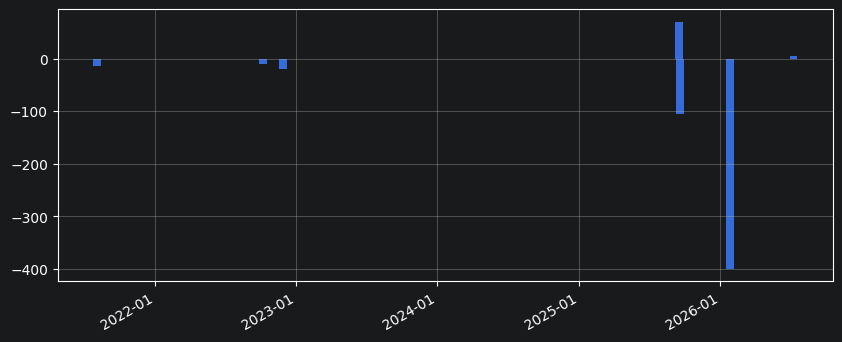

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [14]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,755.00,755.00,610.00,755.00,752.00
mean,0.05,0.06,4020.70,0.14,-0.01
std,36.75,36.75,15861.01,0.32,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,58.91,0.01,0.00
50%,-10.00,-10.00,131.24,0.05,0.00
75%,-1.00,-0.99,300.64,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [15]:
data.nunique().sort_values(ascending=False)

asset_price     601
date            599
asset_amount    597
notes           426
asset_type      176
amount           63
net_amount       62
trans_type       10
trans_id          8
fee               7
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [16]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    526
Deposits                      70
Stock Dividends               52
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [17]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,526,10.37,1.00,10.00,10.00,10.00,50.00
Deposits,70,89.09,1.00,62.50,100.00,100.00,200.00
Stock Dividends,52,0.10,0.01,0.04,0.07,0.15,0.30
Stock Sell,50,10.70,3.00,8.10,10.00,10.08,20.89
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,10,11.90,5.00,9.25,10.00,17.50,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      34
XYZ      15
ORCL     14
JPM      13
AMZN     12
WFC      12
META     12
NFLX     10
V        10
MCD      10
PZZA     10
GOOGL     9
VONV      9
DELL      9
DOW       8
MSFT      8
GOOG      8
UBER      8
INTU      7
VOO       7
VMBS      7
FISV      7
HOOD      7
VGLT      6
UHAL      6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

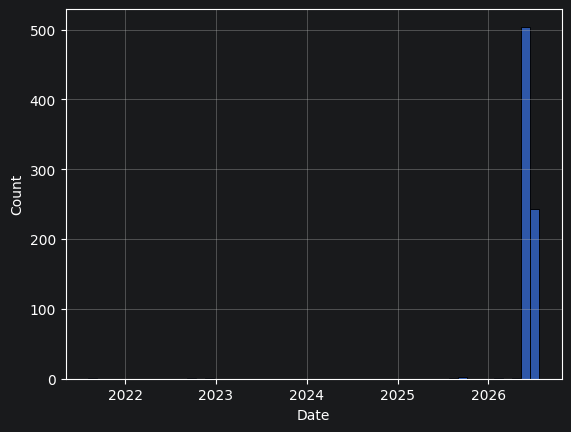

In [19]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [20]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-17,2026-05-27,2026-05-30,2026-06-03,2026-06-04,2026-06-22,2026-07-07,2026-07-16,2026-07-20


In [21]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,34,-127.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 9.0, 10.0, 20.0)",8
XYZ,15,-191.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,14,-109.73,"(-10.0, -5.0, 0.27)",3
JPM,13,-80.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
META,12,-85.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,12,-221.00,"(-50.0, -25.0, -10.0, -1.0)",4
MCD,10,-99.80,"(-25.0, -10.0, -5.0, 0.2)",4
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4


In [22]:
data['currency'].value_counts()

currency
USD    755
Name: count, dtype: int64

In [23]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    526
Deposits                      70
Stock Dividends               52
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [24]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,10,526,52,50,662
BTC,24,10,0,0,0,34
XYZ,0,0,14,0,1,15
ORCL,0,0,13,1,0,14
JPM,0,0,11,0,2,13
WFC,0,0,10,0,2,12
META,0,0,11,1,0,12
AMZN,0,0,12,0,0,12
PZZA,0,0,9,0,1,10


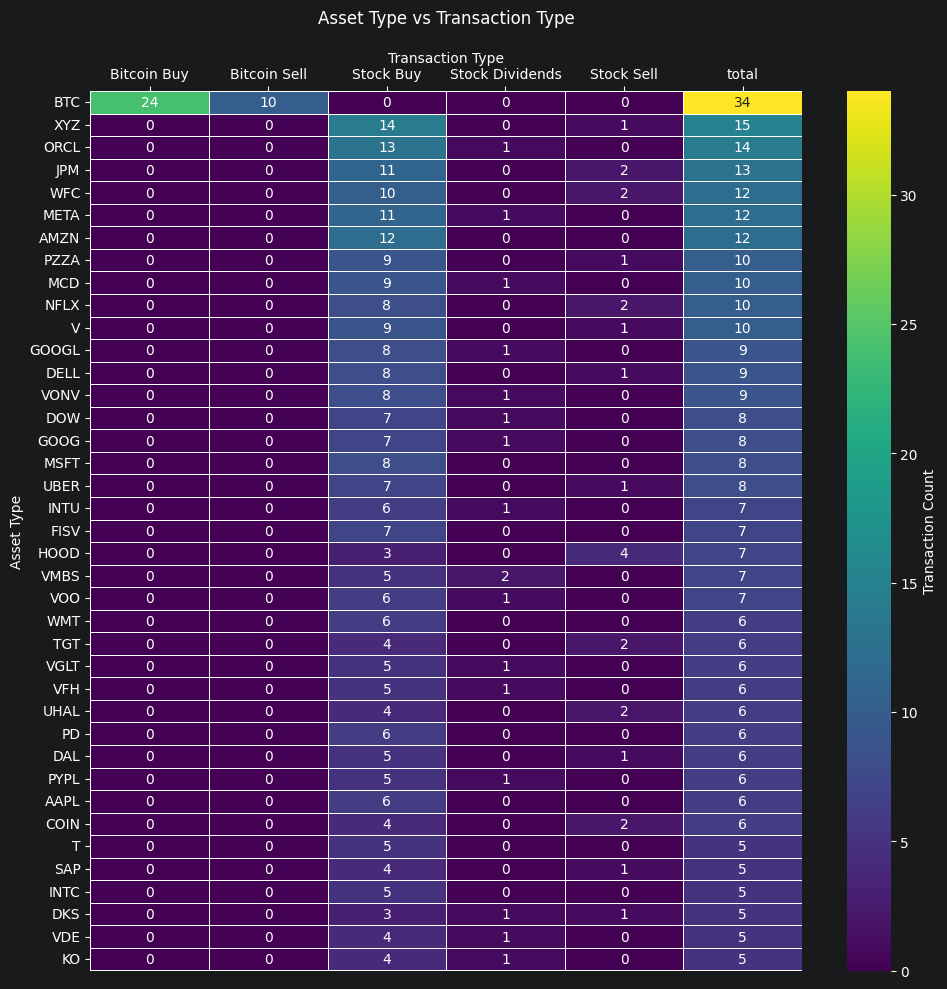

In [25]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [26]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
27,2026-07-16 13:31:06+00:00,8.82,9.0,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN
51,2026-07-11 11:26:39+00:00,9.80,10.0,63645.54,0.000157,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
57,2026-07-10 14:02:46+00:00,9.80,10.0,63970.87,0.000156,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
78,2026-07-06 16:44:23+00:00,9.80,10.0,63170.74,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
90,2026-07-02 17:10:19+00:00,19.60,20.0,61217.07,0.000327,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN


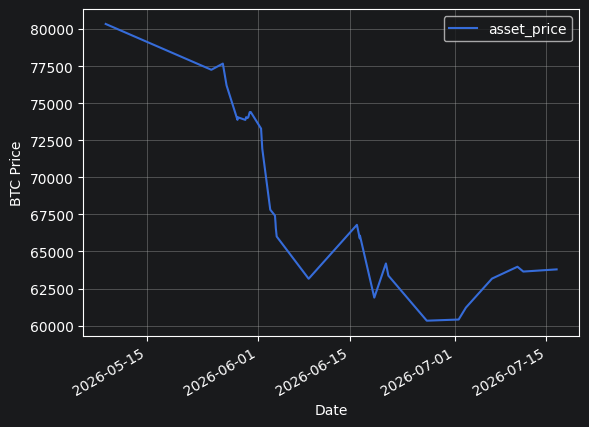

In [27]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [28]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell    10
Name: count, dtype: int64

In [29]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.00
Bitcoin Sell,116.62


In [30]:
data_btc['net_amount'].sum()

np.float64(-135.38)

In [31]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001889
Name: asset_amount, dtype: float64

In [32]:
data_btc['asset_amount'].sum()

np.float64(0.005308329999999999)

In [33]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00153091)

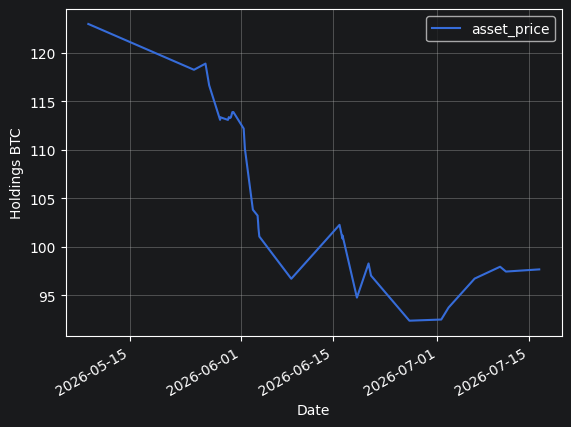

In [34]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [35]:
data_btc['asset_price'] * data_btc['asset_amount']

27      8.999780
51      9.999987
57      9.999926
78      9.999928
90     20.000229
118     9.800290
155     4.900090
210    10.000046
212     4.899747
221    19.999846
303     5.000156
304     4.999899
307     4.900240
343    19.999798
423     9.799846
450     9.800287
474     0.980144
571     9.800221
582     0.979969
599     9.799652
657     4.900136
659     9.799865
662     4.900112
663     9.799903
667     9.799965
671    24.500200
678    24.499951
682    24.500084
701     9.799731
705     9.800031
728    24.499991
745     9.799898
746     4.900356
747     9.799819
dtype: float64

In [36]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
6,2026-07-21 13:33:10+00:00,-10.0,-10.0,79.31,0.12608,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
73,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
154,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
183,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
265,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
310,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
358,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
434,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
446,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
459,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


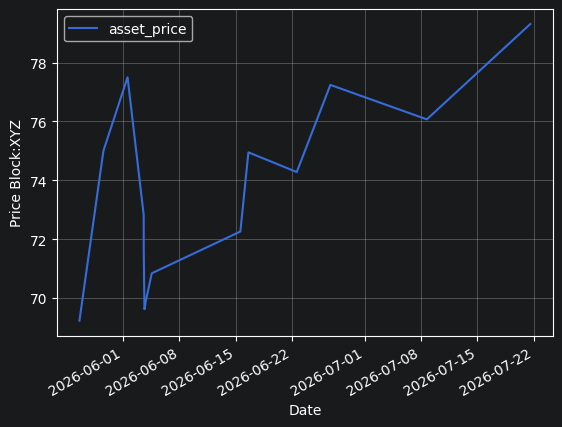

In [37]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [38]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     34
XYZ     15
ORCL    14
JPM     13
WFC     12
        ..
SHOP     1
SLAB     1
SNAP     1
CBRS     1
ZG       1
Name: amount, Length: 176, dtype: int64

In [39]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [40]:
data['asset_amount'].describe()

count    755.000000
mean       0.137184
std        0.318898
min        0.000000
25%        0.007405
50%        0.045710
75%        0.128375
max        4.509170
Name: asset_amount, dtype: float64

In [41]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
147,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
220,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
484,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
609,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [42]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:09+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.0,21.666750,0.000000,0.000000,0.000000,0.000000
2026-06-03 13:30:16+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000e+00,30.766264,9.686363,19.992722,0.0,93.073427,0.000000,9.953370,0.000000,0.000000
2026-06-03 15:19:46+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,41.665912,9.686363,27.762524,0.0,99.663815,19.945984,9.953370,0.000000,0.000000
2026-06-16 13:30:03+00:00,28.691891,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,77.322328,18.724670,27.762524,0.0,171.075624,30.191289,9.953370,9.999727,9.999925
2026-06-18 17:09:55+00:00,28.691891,9.999493,16.180396,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,85.406771,23.724046,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-18 17:14:33+00:00,28.691891,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,85.406771,23.724046,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-22 13:30:58+00:00,37.937295,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,0.000000e+00,85.406771,23.724046,27.762524,0.0,174.501547,42.997334,19.954137,9.999727,9.999925
2026-07-01 13:42:52+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.113515e+00,58.199610,23.724046,27.762524,0.0,178.314166,42.997334,19.954137,9.999727,9.999925
2026-07-01 19:14:58+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.113515e+00,58.199610,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925


In [43]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(4125.906528500001)

In [44]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    212.311076
XYZ     206.333689
DELL    117.932301
MCD      98.010046
UBER     96.165081
Name: 2026-07-24 13:30:12+00:00, dtype: float64

In [45]:
asset_holding_time_last.tail()

asset_type
VBR     0.000000e+00
HPQ     0.000000e+00
ORCL    0.000000e+00
WEN    -8.337775e-16
BTC              NaN
Name: 2026-07-24 13:30:12+00:00, dtype: float64

In [46]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['ADP', 'ALKT', 'AMX', 'AVGO', 'BBEU', 'BNDX', 'CRM', 'CSCO', 'CXSE',
       'DIS', 'DKS', 'EMB', 'FIS', 'GM', 'GSLC', 'HPQ', 'ILMN', 'INTU', 'KO',
       'KWEB', 'LECO', 'NOBL', 'NVDA', 'ORCL', 'OWL', 'OXY', 'POR', 'PSKY',
       'QCOM', 'RUM', 'RUN', 'TSM', 'VBR', 'VDC', 'VFH', 'VHT', 'VMBS', 'VNQ',
       'VONG', 'VSS', 'VTEB', 'XLB'],
      dtype='str', name='asset_type')

In [47]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
147,ADP,$0.15 Dividend from Automatic Data Processing
484,ADP,$10 Purchase of Automatic Data Processing
609,ADP,$10 Purchase of Automatic Data Processing
220,ADP,$10 Purchase of Automatic Data Processing
101,ALKT,$20.89 Sale of Alkami Technology
...,...,...
87,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
242,VTEB,$5 Purchase of Vanguard Tax-Exempt Bond ETF
646,VTEB,$10 Purchase of Vanguard Tax-Exempt Bond ETF
568,XLB,$10 Purchase of Materials Select Sector SPDR


In [48]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-20 13:30:06+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.047586,0.012845,0.004836,0.002424,0.002424
2026-07-20 13:30:26+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.047586,0.012845,0.004836,0.002424,0.002424
2026-07-21 13:33:10+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.050009,0.012845,0.004836,0.002424,0.002424
2026-07-24 13:30:00+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.050009,0.012845,0.004836,0.002424,0.002424
2026-07-24 13:30:12+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.050009,0.012845,0.004836,0.002424,0.002424


In [49]:
asset_price_rel.iloc[-1].describe()

count    1.750000e+02
mean     5.714286e-03
std      7.487664e-03
min     -2.020835e-19
25%      1.953437e-03
50%      3.753414e-03
75%      7.211726e-03
max      5.145804e-02
Name: 2026-07-24 13:30:12+00:00, dtype: float64

In [50]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.051458
XYZ     0.050009
DELL    0.028583
MCD     0.023755
UBER    0.023308
Name: 2026-07-24 13:30:12+00:00, dtype: float64

In [51]:
asset_price_rel_last.tail()

asset_type
VBR     0.000000e+00
HPQ     0.000000e+00
ORCL    0.000000e+00
WEN    -2.020835e-19
BTC              NaN
Name: 2026-07-24 13:30:12+00:00, dtype: float64

<Axes: ylabel='Frequency'>

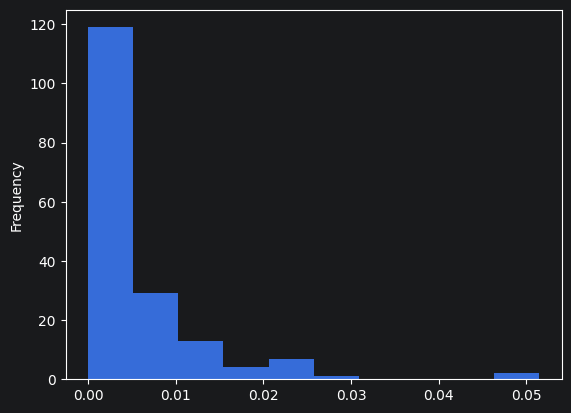

In [52]:
asset_price_rel_last.plot.hist()

In [53]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-20 13:30:06+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.047586,0.012845,0.004836,0.002424,0.002424
2026-07-20 13:30:26+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.047586,0.012845,0.004836,0.002424,0.002424
2026-07-21 13:33:10+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.050009,0.012845,0.004836,0.002424,0.002424
2026-07-24 13:30:00+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.050009,0.012845,0.004836,0.002424,0.002424
2026-07-24 13:30:12+00:00,0.01486,0.002424,0.003922,0.004454,0.0,0.002424,0.0,0.005102,0.002192,0.007288,...,-2.020835e-19,0.015318,0.00575,0.014325,0.0,0.050009,0.012845,0.004836,0.002424,0.002424


In [54]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-16 13:35:28+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:24:53+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-24 13:30:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-02 18:14:25+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 15:08:22+00:00,NaN,NaN,NaN,NaN,226.23,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:32:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 15:47:18+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 18:46:30+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 15:28:36+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-16 13:35:28+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.195860,1.124661,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-06-03 19:24:53+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-06-24 13:30:02+00:00,0.969248,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.072945,1.005550,0.995338,1.0,1.0
2026-06-02 18:14:25+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0
2026-06-03 15:08:22+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.955619,1.0,1.034089,1.000000,1.000000,1.0,1.0
2026-06-03 19:32:10+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-06-16 15:47:18+00:00,1.018386,1.0,0.901125,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.095982,0.968648,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-03 18:46:30+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.006356,1.000000,1.000000,1.0,1.0
2026-07-10 15:28:36+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

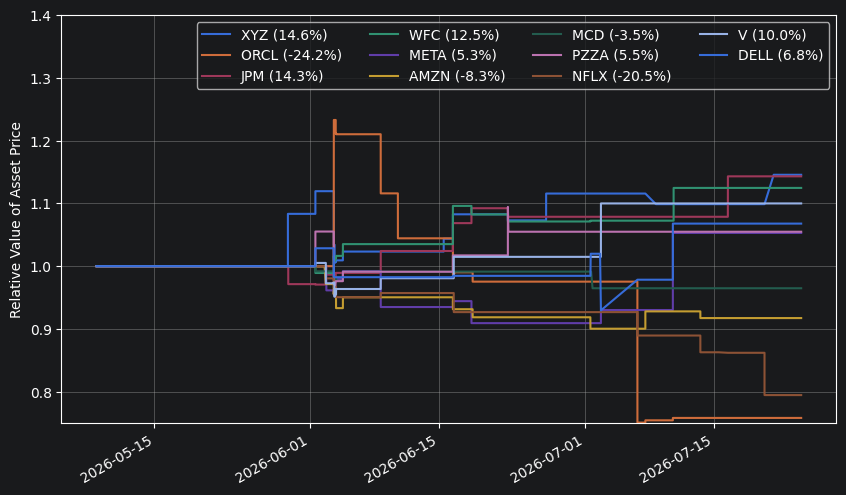

In [56]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(10, 6))
asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=4, loc='upper right')
plt.ylim(0.75, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [57]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-20 13:30:06+00:00    1.098801
2026-07-20 13:30:26+00:00    1.098801
2026-07-21 13:33:10+00:00    1.145602
2026-07-24 13:30:00+00:00    1.145602
2026-07-24 13:30:12+00:00    1.145602
Name: XYZ, Length: 482, dtype: float64

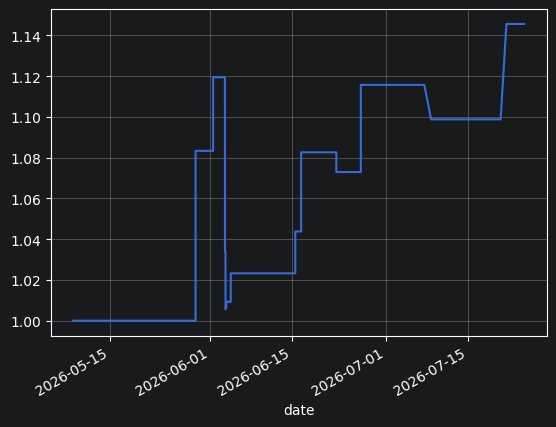

In [58]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [59]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
2,2026-07-24,0.27,ORCL,$0.27 Dividend from Oracle
5,2026-07-22,0.15,DIS,$0.15 Dividend from Disney
3,2026-07-22,0.30,AMX,$0.30 Dividend from America Movil
4,2026-07-22,0.07,CSCO,$0.07 Dividend from Cisco Systems
15,2026-07-17,0.22,INTU,$0.22 Dividend from Intuit
41,2026-07-15,0.03,LECO,$0.03 Dividend from Lincoln Electric
42,2026-07-15,0.01,TMO,$0.01 Dividend from Thermo Fisher Scientific
43,2026-07-15,0.16,OXY,$0.16 Dividend from Occidental Petroleum
44,2026-07-15,0.11,POR,$0.11 Dividend from Portland General Electric ...
70,2026-07-09,0.02,TSM,$0.02 Dividend from Taiwan Semiconductor Manuf...


In [60]:
div_data['amount'].sum()

np.float64(5.35)

In [61]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
3,2026-07-22,0.30,AMX,$0.30 Dividend from America Movil
159,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
2,2026-07-24,0.27,ORCL,$0.27 Dividend from Oracle
144,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
166,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
15,2026-07-17,0.22,INTU,$0.22 Dividend from Intuit
162,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
305,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
156,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
145,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola


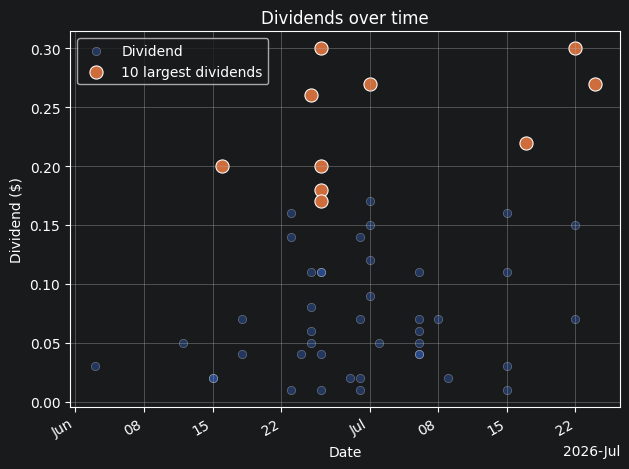

In [62]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [63]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
129,2026-07-01 14:17:44+00:00,-10.00,686.18,$10 Purchase of Vanguard S&P 500 ETF,VOO
461,2026-06-03 15:49:05+00:00,-10.00,275.30,$10 Purchase of Vanguard Health Care ETF,VHT
176,2026-06-23 04:00:00+00:00,0.16,NaN,$0.16 Dividend from Vanguard FTSE All World ex...,VSS
0,2026-07-24 13:30:12+00:00,-20.00,53.33,$20 Purchase of Vanguard Long-Treasury ETF,VGLT
638,2026-06-01 13:30:11+00:00,-10.00,125.85,$10 Purchase of Vanguard Financials ETF,VFH
535,2026-06-03 13:30:10+00:00,-1.00,164.64,$1 Purchase of Energy ETF Vanguard,VDE
175,2026-06-23 04:00:00+00:00,0.14,NaN,$0.14 Dividend from Vanguard Russell 1000 Valu...,VONV
227,2026-06-18 17:09:02+00:00,-10.00,126.88,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
89,2026-07-06 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Mortgage-Backed S...,VMBS
397,2026-06-03 19:46:16+00:00,-10.00,275.16,$10 Purchase of Vanguard Health Care ETF,VHT


In [64]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VGLT    6
VFH     6
VDE     5
BIV     4
VCR     4
VNQ     4
VHT     4
VSS     4
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BND     2
BSV     2
VGT     1
Name: count, dtype: int64

In [65]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
129,2026-07-01 14:17:44+00:00,-10.00,686.18,VOO,Vanguard S&P 500 ETF
461,2026-06-03 15:49:05+00:00,-10.00,275.30,VHT,Vanguard Health Care ETF
176,2026-06-23 04:00:00+00:00,0.16,NaN,VSS,NaN
0,2026-07-24 13:30:12+00:00,-20.00,53.33,VGLT,Vanguard Long-Treasury ETF
638,2026-06-01 13:30:11+00:00,-10.00,125.85,VFH,Vanguard Financials ETF
535,2026-06-03 13:30:10+00:00,-1.00,164.64,VDE,Energy ETF Vanguard
175,2026-06-23 04:00:00+00:00,0.14,NaN,VONV,NaN
227,2026-06-18 17:09:02+00:00,-10.00,126.88,VONG,Vanguard Russell 1000 Growth ETF
89,2026-07-06 04:00:00+00:00,0.11,NaN,VMBS,NaN
397,2026-06-03 19:46:16+00:00,-10.00,275.16,VHT,Vanguard Health Care ETF


In [66]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                8
VOO         Vanguard S&P 500 ETF                           6
VGLT        Vanguard Long-Treasury ETF                     5
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BIV         Vanguard Intermediate Term Bond ETF            3
VCR         Vanguard Consumer Discretionary ETF            3
BND         Vanguard Total Bond Market ETF                 2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
VBR         Small Cap Value ETF Vanguard                   2
BSV         Vanguard Short Te

In [67]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VOO,VMBS,VGLT,VFH,VDE,BIV,VCR,VNQ,VHT,VSS,BNDX,VTEB,VBR,VDC,VONG,BND,BSV,VGT
date,,,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VGLT    6
VFH     6
VDE     5
BIV     4
VCR     4
VNQ     4
VHT     4
VSS     4
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BND     2
BSV     2
VGT     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

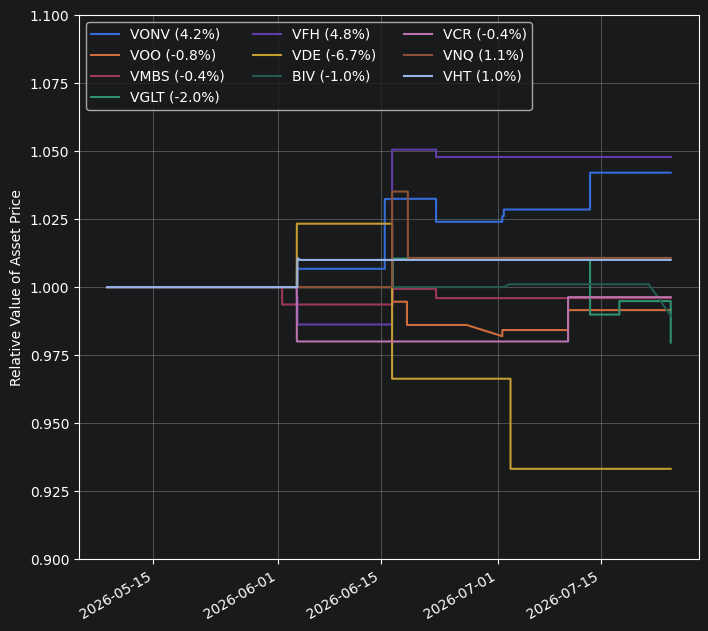

In [69]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.head(10).index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.ylim(0.9, 1.1)
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [70]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
14,2026-07-17 09:46:47+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
16,2026-07-16 22:04:59+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
39,2026-07-16 09:35:34+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
52,2026-07-10 21:11:17+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
68,2026-07-10 13:17:39+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
739,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
740,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
741,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
742,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [71]:
data_deposits['net_amount'].sum()

np.float64(6235.96)

In [72]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,70.0,89.085143,48.213537,1.0,62.5,100.0,100.0,200.0


In [73]:
data_deposits['net_amount'].cumsum()

14      100.00
16      200.00
39      300.00
52      400.00
68      500.00
        ...   
739    6130.96
740    6140.96
741    6190.96
742    6210.96
743    6235.96
Name: net_amount, Length: 70, dtype: float64

In [74]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
743,2026-05-26 19:39:34+00:00,25.00
742,2026-05-26 21:58:29+00:00,45.00
741,2026-05-27 00:43:01+00:00,95.00
740,2026-05-27 00:56:05+00:00,105.00
739,2026-05-27 00:56:27+00:00,205.00
...,...,...
68,2026-07-10 13:17:39+00:00,5835.96
52,2026-07-10 21:11:17+00:00,5935.96
39,2026-07-16 09:35:34+00:00,6035.96
16,2026-07-16 22:04:59+00:00,6135.96


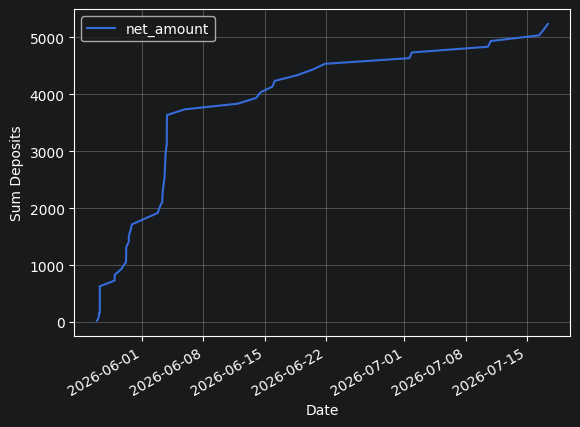

In [75]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [76]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [77]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4900.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64